# Lab 2: Classification Using KNN and Radius Neighbors (RNN)

**Name:** Ruchitha Musku  
**University:** University of the Cumberlands  
**Course:** 2026 Fall - Advanced Big Data and Data Mining (MSCS-634-M50) - Full Term  
**Instructor:** Professor Satish Penmatsa  
**Assignment:** Lab 2 – Exploring K-Nearest Neighbors and Radius Neighbors Classifiers on the Wine Dataset  
**Date:** September 27, 2026

## Overview
This lab compares two instance-based classifiers from scikit-learn on the Wine dataset:

- **K-Nearest Neighbors (KNN):** predicts using a fixed number (*k*) of closest training points.
- **Radius Neighbors (RNN):** predicts using every training point that lies within a fixed distance (*radius*).

We vary *k* and *radius*, record test accuracy, visualize the trends, and discuss when each model is the better choice.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 100

import os
os.makedirs('images', exist_ok=True)  # folder for saved plot images

## Step 1: Load and Prepare the Dataset

In [2]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

print('Dataset shape (samples, features):', X.shape)
print('Class names:', list(wine.target_names))
X.head()

Dataset shape (samples, features): (178, 13)
Class names: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### Feature details

In [3]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [4]:
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


In [5]:
print('Missing values in the dataset:', X.isnull().sum().sum())

Missing values in the dataset: 0


### Class distribution

class_0    59
class_1    71
class_2    48
Name: count, dtype: int64

Class proportions:
class_0    0.331
class_1    0.399
class_2    0.270
Name: count, dtype: float64


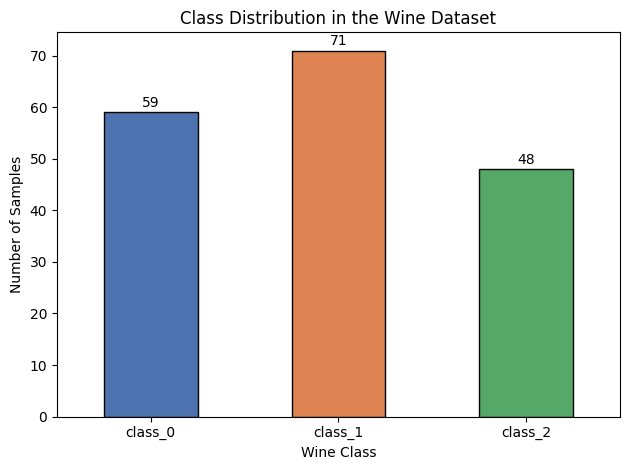

In [6]:
class_counts = y.value_counts().sort_index()
class_counts.index = wine.target_names
print(class_counts)
print('\nClass proportions:')
print((class_counts / len(y)).round(3))

ax = class_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
ax.set_title('Class Distribution in the Wine Dataset')
ax.set_xlabel('Wine Class')
ax.set_ylabel('Number of Samples')
plt.xticks(rotation=0)
for i, v in enumerate(class_counts):
    ax.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.savefig('images/class_distribution.png', bbox_inches='tight')
plt.show()

**Observations from exploration**

- The dataset has **178 samples**, **13 numeric chemical features**, and **3 classes** (class_0: 59, class_1: 71, class_2: 48). The classes are moderately balanced, so accuracy is a reasonable metric.
- There are **no missing values**.
- Feature scales differ greatly: `proline` ranges from roughly 278 to 1680 and `magnesium` from 70 to 162, while features like `hue` or `nonflavanoid_phenols` are below 2. Because KNN and RNN use Euclidean distance, distances on the raw data are dominated by `proline`. This also explains why the radius values given in the lab (350–600) are in the hundreds: they only make sense on unscaled data. The models below therefore use the **raw features**, as the lab's parameter ranges intend. A short scaled comparison appears at the end.

### Train/test split (80% / 20%)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Training set:', X_train.shape)
print('Testing set: ', X_test.shape)
print('\nTest-set class counts:')
print(y_test.value_counts().sort_index().rename(index=dict(enumerate(wine.target_names))))

Training set: (142, 13)
Testing set:  (36, 13)

Test-set class counts:
target
class_0    12
class_1    14
class_2    10
Name: count, dtype: int64


The split uses `stratify=y` so each class keeps the same proportion in the training and test sets, and `random_state=42` so the results are reproducible.

## Step 2: Implement K-Nearest Neighbors (KNN)

In [8]:
k_values = [1, 5, 11, 15, 21]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_results.append({'k': k, 'Accuracy': acc})
    print(f'k = {k:>2}  ->  Test Accuracy = {acc:.4f}')

knn_df = pd.DataFrame(knn_results)
knn_df

k =  1  ->  Test Accuracy = 0.7778
k =  5  ->  Test Accuracy = 0.8056
k = 11  ->  Test Accuracy = 0.8056
k = 15  ->  Test Accuracy = 0.8056
k = 21  ->  Test Accuracy = 0.8056


,k,Accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


## Step 3: Implement Radius Neighbors (RNN)

`outlier_label='most_frequent'` is set as a safeguard: if a test point had no training points inside the radius, the classifier would otherwise raise an error. The cell also records how many neighbors fall inside each radius, which helps explain the accuracy trend.

In [9]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_results = []

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    rnn.fit(X_train, y_train)
    y_pred = rnn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Number of training neighbors found within the radius for each test point
    neigh_idx = rnn.radius_neighbors(X_test, return_distance=False)
    n_neighbors = np.array([len(idx) for idx in neigh_idx])

    rnn_results.append({
        'Radius': r,
        'Accuracy': acc,
        'Min neighbors': n_neighbors.min(),
        'Avg neighbors': round(n_neighbors.mean(), 1),
        'Max neighbors': n_neighbors.max(),
    })
    print(f'radius = {r}  ->  Test Accuracy = {acc:.4f}  (avg neighbors = {n_neighbors.mean():.1f})')

rnn_df = pd.DataFrame(rnn_results)
rnn_df

radius = 350  ->  Test Accuracy = 0.7222  (avg neighbors = 80.5)
radius = 400  ->  Test Accuracy = 0.6944  (avg neighbors = 87.9)
radius = 450  ->  Test Accuracy = 0.6944  (avg neighbors = 94.8)
radius = 500  ->  Test Accuracy = 0.6944  (avg neighbors = 100.1)
radius = 550  ->  Test Accuracy = 0.6667  (avg neighbors = 106.0)
radius = 600  ->  Test Accuracy = 0.6667  (avg neighbors = 111.0)


,Radius,Accuracy,Min neighbors,Avg neighbors,Max neighbors
0,350,0.722222,4,80.5,111
1,400,0.694444,9,87.9,121
2,450,0.694444,14,94.8,126
3,500,0.694444,17,100.1,136
4,550,0.666667,19,106.0,138
5,600,0.666667,23,111.0,140


## Step 4: Visualize and Compare Results

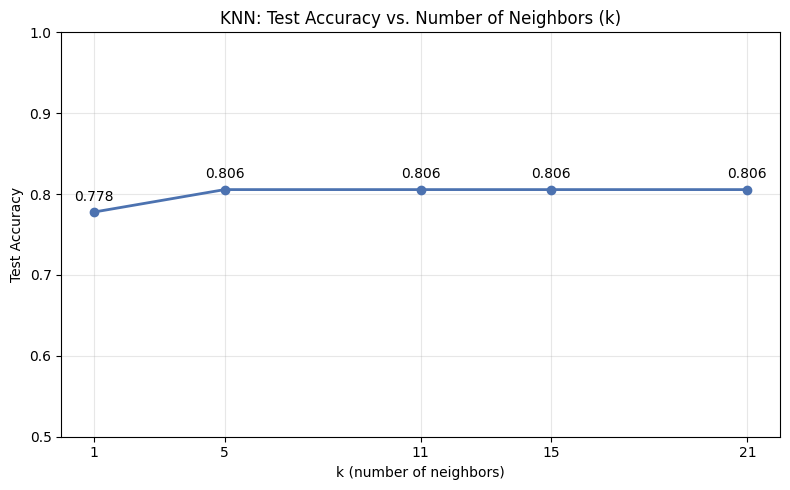

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(knn_df['k'], knn_df['Accuracy'], marker='o', linewidth=2, color='#4C72B0')
for k, acc in zip(knn_df['k'], knn_df['Accuracy']):
    ax.annotate(f'{acc:.3f}', (k, acc), textcoords='offset points', xytext=(0, 8), ha='center')
ax.set_title('KNN: Test Accuracy vs. Number of Neighbors (k)')
ax.set_xlabel('k (number of neighbors)')
ax.set_ylabel('Test Accuracy')
ax.set_xticks(k_values)
ax.set_ylim(0.5, 1.0)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/knn_accuracy.png', bbox_inches='tight')
plt.show()

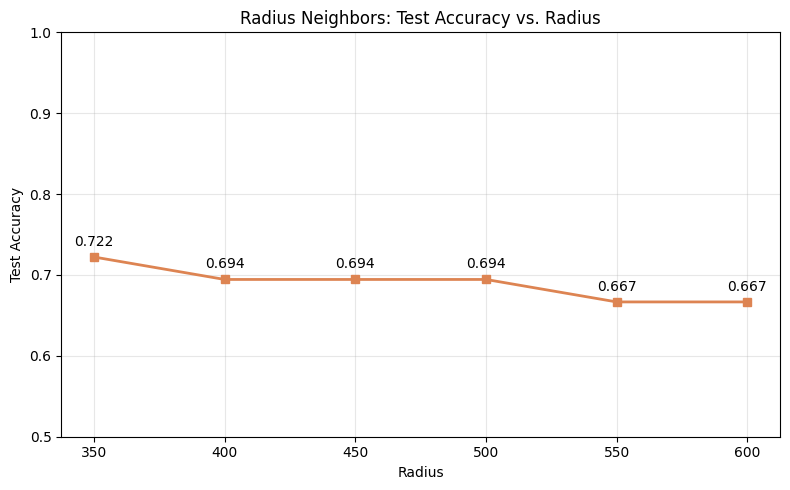

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rnn_df['Radius'], rnn_df['Accuracy'], marker='s', linewidth=2, color='#DD8452')
for r, acc in zip(rnn_df['Radius'], rnn_df['Accuracy']):
    ax.annotate(f'{acc:.3f}', (r, acc), textcoords='offset points', xytext=(0, 8), ha='center')
ax.set_title('Radius Neighbors: Test Accuracy vs. Radius')
ax.set_xlabel('Radius')
ax.set_ylabel('Test Accuracy')
ax.set_xticks(radius_values)
ax.set_ylim(0.5, 1.0)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/rnn_accuracy.png', bbox_inches='tight')
plt.show()

### Side-by-side comparison

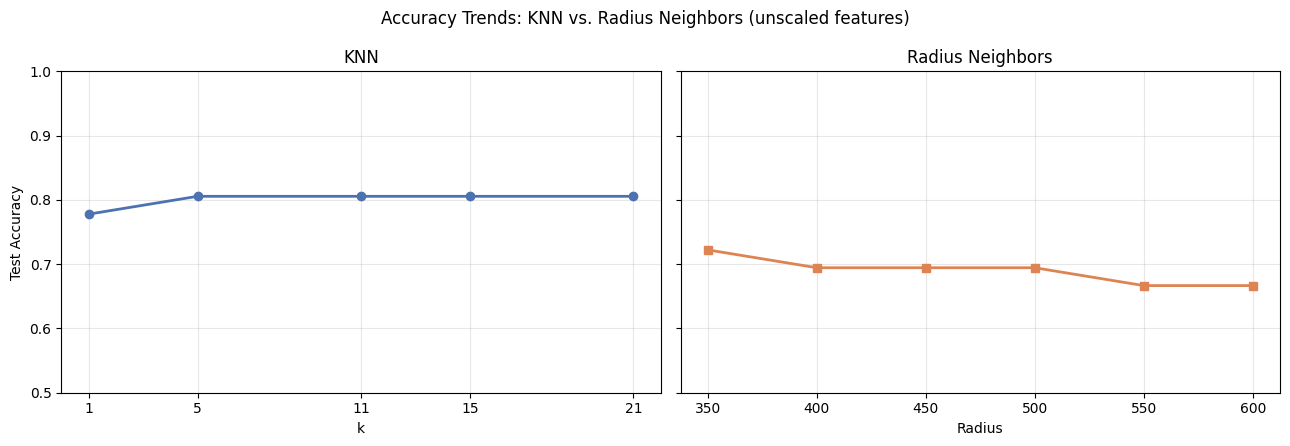

,Model,Best parameter,Best accuracy,Worst accuracy,Mean accuracy
0,KNN,k = 5,0.8056,0.7778,0.8000
1,Radius Neighbors,radius = 350,0.7222,0.6667,0.6898


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
axes[0].plot(knn_df['k'], knn_df['Accuracy'], marker='o', linewidth=2, color='#4C72B0')
axes[0].set_title('KNN')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_xticks(k_values)
axes[1].plot(rnn_df['Radius'], rnn_df['Accuracy'], marker='s', linewidth=2, color='#DD8452')
axes[1].set_title('Radius Neighbors')
axes[1].set_xlabel('Radius')
axes[1].set_xticks(radius_values)
for ax in axes:
    ax.set_ylim(0.5, 1.0)
    ax.grid(alpha=0.3)
fig.suptitle('Accuracy Trends: KNN vs. Radius Neighbors (unscaled features)')
plt.tight_layout()
plt.savefig('images/knn_vs_rnn_comparison.png', bbox_inches='tight')
plt.show()

summary = pd.DataFrame({
    'Model': ['KNN', 'Radius Neighbors'],
    'Best parameter': [
        f"k = {int(knn_df.loc[knn_df['Accuracy'].idxmax(), 'k'])}",
        f"radius = {int(rnn_df.loc[rnn_df['Accuracy'].idxmax(), 'Radius'])}",
    ],
    'Best accuracy': [knn_df['Accuracy'].max(), rnn_df['Accuracy'].max()],
    'Worst accuracy': [knn_df['Accuracy'].min(), rnn_df['Accuracy'].min()],
    'Mean accuracy': [knn_df['Accuracy'].mean(), rnn_df['Accuracy'].mean()],
}).round(4)
summary

### Additional check: effect of feature scaling
This is not required by the lab, but it explains the accuracy levels above. The features are standardized and KNN is re-run. RNN radii of 350–600 would include every training point once the data is scaled, so only KNN is shown here.

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

scaled_results = []
for k in k_values:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_train, y_train)
    scaled_results.append({'k': k, 'Accuracy (scaled)': accuracy_score(y_test, model.predict(X_test))})

scaled_df = pd.DataFrame(scaled_results).merge(
    knn_df.rename(columns={'Accuracy': 'Accuracy (unscaled)'}), on='k')
scaled_df.round(4)

,k,Accuracy (scaled),Accuracy (unscaled)
0,1,0.9722,0.7778
1,5,0.9722,0.8056
2,11,1.0000,0.8056
3,15,1.0000,0.8056
4,21,1.0000,0.8056


## Discussion

### Comparison of the two models

**KNN**
- Accuracy rose from **77.8% at k = 1** to **80.6% for k = 5 through 21**, then stayed flat.
- With k = 1 the model relies on a single neighbor, so one noisy or atypical training sample can flip a prediction (high variance/overfitting). Averaging over 5 or more neighbors smooths this out.
- The plateau from k = 5 to k = 21 shows that KNN is fairly **robust** to the choice of k on this dataset once k is not too small.

**Radius Neighbors**
- Accuracy was highest at **radius = 350 (72.2%)** and **declined** as the radius grew: 69.4% for 400–500 and 66.7% for 550–600.
- The neighbor counts explain the drop. At radius 350 a test point already has about 80 of the 142 training samples inside its radius on average. At radius 600 the average is about 111. With so many neighbors the vote moves toward the majority class, and the local structure that makes neighbor methods work is lost (underfitting).
- Every radius in the lab's range is large relative to the data, so all RNN settings fall on the "too smooth" side of the bias–variance tradeoff.

**Overall:** KNN outperformed RNN at every tested setting. KNN's best accuracy was 80.6% and RNN's best was 72.2%. KNN was also more stable across its parameter range. RNN was sensitive to the radius, and accuracy fell steadily as the radius increased.

A common factor limits both models: the features are unscaled, so distances are dominated by `proline`. The scaling check shows KNN accuracy rising from about 78–81% to **97–100%** once features are standardized. In practice, scaling is the first thing to fix before tuning k or the radius.

### When might KNN or RNN be preferable?

**KNN is preferable when:**
- Data density varies across the feature space. KNN always uses k neighbors, so it adapts automatically to both dense and sparse regions.
- You want a parameter that is easy to tune and does not depend on the units or scale of the features. A reasonable k (e.g., 5–15) works across many datasets, while a good radius must be tuned for each dataset's distance scale.
- Every test point must receive a prediction from its own neighborhood. RNN can find zero neighbors for isolated points.

This lab matches that profile: a small dataset (178 samples) with features on very different scales.

**RNN is preferable when:**
- Data is fairly uniformly dense and the distance scale is meaningful. For example, "similar" can be defined physically, as in geographic or sensor data where points within X meters or units count as related.
- Outlier or novelty detection is useful. Points with no neighbors inside the radius can be flagged instead of being forced into a class, which KNN cannot do.
- Dense regions should use more evidence than sparse ones, since the number of neighbors grows naturally with local density.
- The radius is chosen carefully, and usually much smaller than here. Our results show that too large a radius causes RNN to collapse toward majority-class voting.

### Conclusion
On the Wine dataset with the given parameter ranges, **KNN with k ≥ 5 was the better choice**, reaching about 80.6% accuracy. **Radius Neighbors peaked at about 72.2% with the smallest radius (350)** and declined as the radius grew. This shows how directly parameter choices control the bias–variance tradeoff in neighbor-based classifiers.